# OOI Pioneer NES Discrete Water Samples 

## Goal of this notebook: Quickly plot OOI's Water Sampling data from an Array over time for several parameters

The NSF Ocean Observatories Initiative (OOI) provides Discrete CTD and Water Sampling Cruise Data for each Array as a dataset in the Biological and Chemical Oceanography Data Management Office (BCO-DMO). This notebook plots Oxygen, Salinity, and Nitrate data from the Coastal Pioneer NES Array from 2014 to 2022. [DOI]

## Set Up

The GitHub repository containing this notebook includes information about dependencies (and versions) in .yml files.

In [106]:
# Import modules
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib.dates import AutoDateLocator, AutoDateFormatter
import cmocean.cm as cmo # colormaps for commonly-used oceanographic variables
import seaborn as sns

In [2]:
# print(mpl.__version__) # if plot cell results in error check version of matplotlib

## Load OOI data into workspace

To access the data in comma separated variable (CSV) format, one can either:

1. Access the File through the URL at ERDDAP > Files (shown below)
2. Generate a URL using the ERDDAP Data Access Form
    * If using the ERDDAP Data Access Form, file type .csvp provides a single header row.
    * If using the ERDDAP Data Access Form, one can subset (e.g., select variables of interest) prior to loading the data.

In [5]:
# place holder to pull in from ERDDAP once the data is available through that server

In [19]:
# Load data into a Pandas Dataframe
df = pd.read_csv("./data/966896_v1_ooi_pioneer_nes_ctd_and_water_sampling_data.csv")
df.head() # Print the first 5 rows of the DataFrame

,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
0,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KN217,001,PMUI,40.361667,-70.771833,2014-04-12T18:06:29.000Z,001,*0000000000000100,96.0,kn217001.hex,...,*0000000000000100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
print(df.columns)

Index(['Cruise', 'Station', 'Target_Asset', 'Start_Latitude',
       'Start_Longitude', 'Start_Time', 'Cast', 'Cast_Flag',
       'Bottom_Depth_at_Start_Position', 'CTD_File', 'CTD_File_Flag',
       'Niskin_Bottle_Position', 'Niskin_Flag', 'CTD_Bottle_Closure_Time',
       'CTD_Pressure', 'CTD_Pressure_Flag', 'CTD_Depth', 'CTD_Latitude',
       'CTD_Longitude', 'CTD_Temperature_1', 'CTD_Temperature_1_Flag',
       'CTD_Temperature_2', 'CTD_Temperature_2_Flag', 'CTD_Conductivity_1',
       'CTD_Conductivity_1_Flag', 'CTD_Conductivity_2',
       'CTD_Conductivity_2_Flag', 'CTD_Salinity_1', 'CTD_Salinity_2',
       'CTD_Oxygen', 'CTD_Oxygen_Flag', 'CTD_Oxygen_Saturation',
       'CTD_Fluorescence', 'CTD_Fluorescence_Flag', 'CTD_Beam_Attenuation',
       'CTD_Beam_Transmission', 'CTD_Transmissometer_Flag', 'CTD_pH',
       'CTD_pH_Flag', 'Discrete_Oxygen', 'Discrete_Oxygen_Flag',
       'Discrete_Oxygen_Replicate_Flag', 'Discrete_Chlorophyll',
       'Discrete_Phaeopigment', 'Discrete_Fo_

In [22]:
# Convert the CTD Bottle Closure Time to a datetime data type
df["CTD_Bottle_Closure_Time"] = pd.to_datetime(df["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True)
df.dtypes["CTD_Bottle_Closure_Time"]

datetime64[ns, UTC]

## Apply QC flags

Apply QC flags
For functions to interpret OOI discrete sample CTD flags to QARTOD QC-flags please see bottles.py file in https://github.com/oceanobservatories/ooi-data-explorations. For your convience, the module has also been included in this repository.

In [23]:
# display unique Discrete Sample flags
# df.Discrete_Oxygen_Flag.unique() # display unique one column
pd.unique(df[["Discrete_Oxygen_Flag", "Discrete_Salinity_Flag", "Discrete_Nutrients_Flag"]].values.ravel('K')) # display unique multiple columns


array(['*0000000000000100', nan, '*0000000000001000', '*0000000000001001',
       '*BD22:BD1170000000000000100', '*0000000000010001',
       '*0000000000000001', '*0000000000000101'], dtype=object)

In [24]:
# Assign "Acceptable" flags to QARTOD 
flag1 = "*0000000000000100" # Good 1 in Bit Position 2 (i.e., 3rd from right)
flag2 = "*0000000000000101" # this example had 2 unique "Acceptable" flags

df.loc[df.Discrete_Oxygen_Flag == flag1, 'Discrete_Oxygen_Flag'] = 1       # assign QARTOD Good
df.loc[df.Discrete_Oxygen_Flag == flag2, 'Discrete_Oxygen_Flag'] = 1       # assign QARTOD Good
df.loc[df.Discrete_Salinity_Flag == flag1, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good
df.loc[df.Discrete_Salinity_Flag == flag2, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good
df.loc[df.Discrete_Nutrients_Flag == flag1, 'Discrete_Nutrients_Flag'] = 1 # assign QARTOD Good
df.loc[df.Discrete_Nutrients_Flag == flag2, 'Discrete_Nutrients_Flag'] = 1 # assign QARTOD Good

# Display unique Discrete Sample flags
pd.unique(df[["Discrete_Oxygen_Flag", "Discrete_Salinity_Flag", "Discrete_Nutrients_Flag"]].values.ravel('K')) # display unique multiple columns


array([1, nan, '*0000000000001000', '*0000000000001001',
       '*BD22:BD1170000000000000100', '*0000000000010001',
       '*0000000000000001'], dtype=object)

In [25]:
# Subset Data Frame to Discrete Samples with Acceptable flags
df_qc = df.query("Discrete_Oxygen_Flag==1 | Discrete_Salinity_Flag==1 | Discrete_Nutrients_Flag==1")
print(f"This subset of Discrete Samples with Acceptable flags reduced the total data points from {len(df)} to {len(df_qc)}")

This subset of Discrete Samples with Acceptable flags reduced the total data points from 3755 to 1875


## Plot Data
Set themes, styles, and figure global parameters

In [26]:
# For indexing multi-panel plots with matplotlib 
flag_oxy = df_qc["Discrete_Oxygen_Flag"]==1
flag_sal = df_qc["Discrete_Salinity_Flag"]==1
flag_ntr = df_qc["Discrete_Nutrients_Flag"]==1

In [27]:
# Assign colormaps from cmocean package
cmap_oxy = cmo.deep_r
cmap_salt = cmo.haline
cmap_nitr = cmo.matter
#cmap_chl = cmo.algae
cmap_time = cmo.tempo_r

In [28]:
# set up time for matplotlib plots
time = df_qc["CTD_Bottle_Closure_Time"].values

# Create a matplotlib-friendly numeric time array
mpl_time = mpl.dates.date2num(time)

# Create normalizer for colorbar representing the full date range
normalizer = Normalize(mpl_time[0], mpl_time[-1])

# Create tick locator for using time as the color scale
locator = AutoDateLocator()

Plot Quality Controlled Data

**Figure 1.** Plot the oxygen, salinity, and nitrate concentrations through time as a function of depth.

Text(0.5, 0, 'Time')

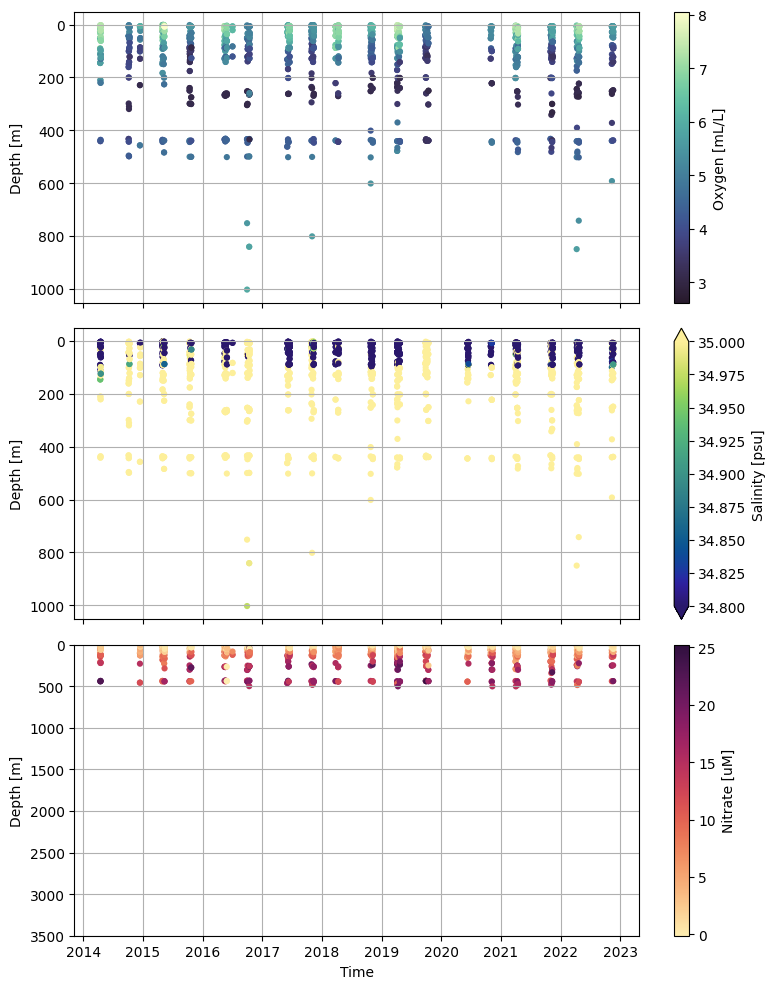

In [33]:
# Create the subplots with time on the x-axis
fig, axs = plt.subplots(3, 1, figsize=(8,10), sharex=True, layout="tight")

# Discrete Oxygen
plt.subplot(3,1,1)
axs[0].invert_yaxis()
plt.scatter(x=time[flag_oxy], y=df_qc["CTD_Depth"][flag_oxy], s=20,
            c=df_qc["Discrete_Oxygen"][flag_oxy], cmap=cmap_oxy,
            edgecolors="none")
plt.grid()
plt.colorbar(label="Oxygen [mL/L]")
axs[0].set_ylabel("Depth [m]")

# Discrete Salinity
plt.subplot(3,1,2)
axs[1].invert_yaxis()
plt.scatter(x=time[flag_sal], y=df_qc["CTD_Depth"][flag_sal], s=20,
            c=df_qc["Discrete_Salinity"][flag_sal], cmap=cmap_salt,
            edgecolors="none", vmin=34.8, vmax=35)
plt.grid()
plt.colorbar(label="Salinity [psu]", extend='both')
axs[1].set_ylabel("Depth [m]")

# Discrete Nitrate
plt.subplot(3,1,3)
axs[2].set_ylim([0, 3500])
axs[2].invert_yaxis()
plt.scatter(x=time[flag_ntr], y=df_qc["CTD_Depth"][flag_ntr], s=20,
            c=df_qc["Discrete_Nitrate"][flag_ntr], cmap=cmap_nitr,
            edgecolors="none")
plt.grid()
plt.colorbar(label="Nitrate [uM]")
axs[2].set_ylabel("Depth [m]")

axs[2].set_xlabel("Time")

**Figure 2.** Plot oxygen, salinity, and nitrate concentrations as a function of depth.

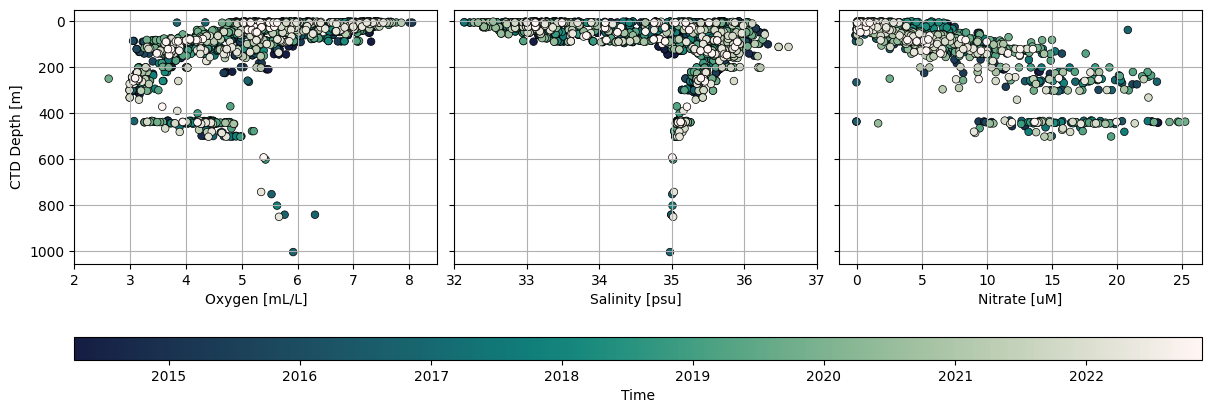

In [40]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, AutoDateFormatter
import matplotlib.cm as cm

# Set up figure and axes
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True, constrained_layout=True)

# Discrete Oxygen
axs[0].invert_yaxis()
sc0 = axs[0].scatter(x=df_qc["Discrete_Oxygen"][flag_oxy],
                     y=df_qc["CTD_Depth"][flag_oxy],
                     s=30, c=mpl_time[flag_oxy],
                     cmap=cmap_time, norm=normalizer,
                     edgecolors="k", linewidths=0.5)
axs[0].grid()
axs[0].set_ylabel("CTD Depth [m]")
axs[0].set_xlabel("Oxygen [mL/L]")
axs[0].set_xlim([2, 8.5]) #changed the scale to show all

# Discrete Salinity
axs[1].invert_yaxis()
sc1 = axs[1].scatter(x=df_qc["Discrete_Salinity"][flag_sal],
                     y=df_qc["CTD_Depth"][flag_sal],
                     s=30, c=mpl_time[flag_sal],
                     cmap=cmap_time, norm=normalizer,
                     edgecolors="k", linewidths=0.5)
axs[1].grid()
axs[1].set_xlabel("Salinity [psu]")
axs[1].set_xlim([32, 37]) #changed the scale to show all

# Discrete Nitrate
axs[2].invert_yaxis()
sc2 = axs[2].scatter(x=df_qc["Discrete_Nitrate"][flag_ntr],
                     y=df_qc["CTD_Depth"][flag_ntr],
                     s=30, c=mpl_time[flag_ntr],
                     cmap=cmap_time, norm=normalizer,
                     edgecolors="k", linewidths=0.5)
axs[2].grid()
axs[2].set_xlabel("Nitrate [uM]")

# Shared colorbar at the bottom
cbar = fig.colorbar(cm.ScalarMappable(norm=normalizer, cmap=cmap_time),
                    ax=axs, orientation="horizontal", aspect=50,
                    pad=0.1, ticks=AutoDateLocator())
cbar.ax.xaxis.set_major_formatter(AutoDateFormatter(locator))
cbar.set_label("Time")

plt.show()

## Additional plots

#### Same as plot above, but year is on x axis and measurement values shown via gradient

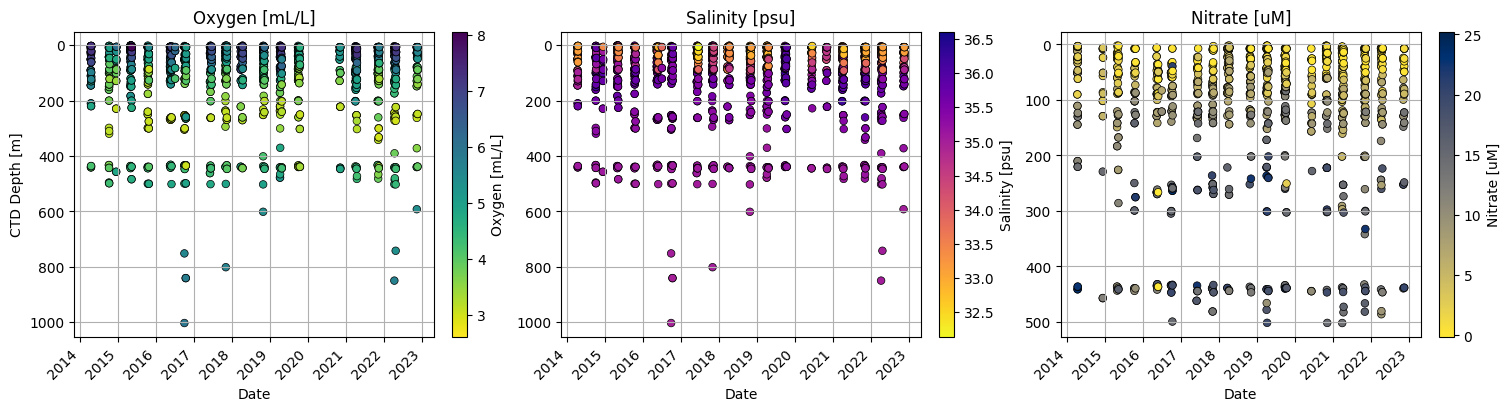

In [42]:
# Create figure and subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=False, constrained_layout=True)

# Discrete Oxygen
sc0 = axs[0].scatter(x=mpl_time[flag_oxy],
                     y=df_qc["CTD_Depth"][flag_oxy],
                     s=30, c=df_qc["Discrete_Oxygen"][flag_oxy],
                     cmap="viridis_r", edgecolors="k", linewidths=0.5)
axs[0].invert_yaxis()
axs[0].grid()
axs[0].set_xlabel("Date")
axs[0].set_ylabel("CTD Depth [m]")
axs[0].set_title("Oxygen [mL/L]")

# Discrete Salinity
sc1 = axs[1].scatter(x=mpl_time[flag_sal],
                     y=df_qc["CTD_Depth"][flag_sal],
                     s=30, c=df_qc["Discrete_Salinity"][flag_sal],
                     cmap="plasma_r", edgecolors="k", linewidths=0.5)
axs[1].invert_yaxis()
axs[1].grid()
axs[1].set_xlabel("Date")
axs[1].set_title("Salinity [psu]")

# Discrete Nitrate
sc2 = axs[2].scatter(x=mpl_time[flag_ntr],
                     y=df_qc["CTD_Depth"][flag_ntr],
                     s=30, c=df_qc["Discrete_Nitrate"][flag_ntr],
                     cmap="cividis_r", edgecolors="k", linewidths=0.5)
axs[2].invert_yaxis()
axs[2].grid()
axs[2].set_xlabel("Date")
axs[2].set_title("Nitrate [uM]")

# Add colorbars
fig.colorbar(sc0, ax=axs[0], orientation="vertical", label="Oxygen [mL/L]")
fig.colorbar(sc1, ax=axs[1], orientation="vertical", label="Salinity [psu]")
fig.colorbar(sc2, ax=axs[2], orientation="vertical", label="Nitrate [uM]")

# Format dates
locator = AutoDateLocator()
formatter = AutoDateFormatter(locator)
for ax in axs:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

# Or automatically adjust
fig.autofmt_xdate()

plt.show()

## Comparing Discrete vs CTD Values per Target Asset for a Single Year


In [86]:
def plot_ctd_vs_discrete_profiles(df, year=2023, variable="Salinity", target_assets=None, depth_col="CTD_Depth"):
    """
    Plots side-by-side CTD and Discrete variable profiles by Target_Asset for a given year.

    - Uses colorblind-friendly warm colors for CTD and cool colors for Discrete.
    - Skips empty plots.
    - Preserves exact column names in legend.

    Parameters:
    - df: pandas DataFrame
    - year: int
    - variable: str (e.g., "Oxygen", "pH")
    - target_assets: list of strings (optional)
    - depth_col: str (default = "CTD_Depth")
    """
    df = df.copy()
    df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")

    # Select relevant columns
    ctd_cols = [col for col in df.columns if col.startswith(f"CTD_{variable}") and "Flag" not in col and "Replicate" not in col]
    disc_cols = [col for col in df.columns if col.startswith(f"Discrete_{variable}") and "Flag" not in col and "Replicate" not in col]

    if not ctd_cols and not disc_cols:
        print(f"❌ No matching CTD or Discrete columns found for variable '{variable}'")
        return

    df_filtered = df[
        (df["Start_Time"].dt.year == year) &
        (df[depth_col].notna()) &
        (df["Target_Asset"].notna())
    ]

    available_assets = sorted(df_filtered["Target_Asset"].dropna().unique())
    if target_assets is None:
        assets_to_plot = available_assets
    else:
        assets_to_plot = [a for a in target_assets if a in available_assets]

    if not assets_to_plot:
        print(f"❌ No valid data for {year} and selected Target_Assets.")
        return

    # Filter only assets with data
    plot_data = []
    for asset in assets_to_plot:
        subset = df_filtered[df_filtered["Target_Asset"] == asset]
        has_data = any(subset[col].notna().any() for col in (ctd_cols + disc_cols))
        if has_data:
            plot_data.append((asset, subset))
        else:
            print(f"⚠️ No data to plot for Target_Asset '{asset}' and variable '{variable}' in {year}.")

    if not plot_data:
        print(f"❌ No data found to plot for variable '{variable}' in {year}.")
        return

    # Color palettes (colorblind-friendly)
    warm_colors = ["#E66100", "#F6C141", "#B62000", "#A95AA1", "#E17C05", "#FFB000"]  # CTD
    cool_colors = ["#5B9BD5", "#0072B2", "#56B4E9", "#117733", "#66C2A5", "#009E73"]  # Discrete

    ctd_colors = {col: warm_colors[i % len(warm_colors)] for i, col in enumerate(ctd_cols)}
    disc_colors = {col: cool_colors[i % len(cool_colors)] for i, col in enumerate(disc_cols)}

    # Plot
    fig, axs = plt.subplots(1, len(plot_data), figsize=(4 * len(plot_data), 6), sharey=True, constrained_layout=True)
    if len(plot_data) == 1:
        axs = [axs]

    for i, (asset, subset) in enumerate(plot_data):
        ax = axs[i]

        for col in ctd_cols:
            col_data = subset.dropna(subset=[col])
            if not col_data.empty:
                ax.plot(col_data[col], col_data[depth_col],
                        label=col, color=ctd_colors[col],
                        marker='o', linestyle='-', linewidth=1.2, alpha=0.85)

        for col in disc_cols:
            col_data = subset.dropna(subset=[col])
            if not col_data.empty:
                ax.plot(col_data[col], col_data[depth_col],
                        label=col, color=disc_colors[col],
                        marker='s', linestyle='--', linewidth=1.2, alpha=0.85)

        ax.invert_yaxis()
        ax.set_title(asset)
        ax.set_xlabel(f"{variable} [units]")
        if i == 0:
            ax.set_ylabel("CTD Depth [m]")
        ax.grid(True)
        ax.legend(fontsize="small")

    plt.suptitle(f"CTD vs Discrete {variable} Profiles by Target Asset ({year})", fontsize=16)
    plt.show()

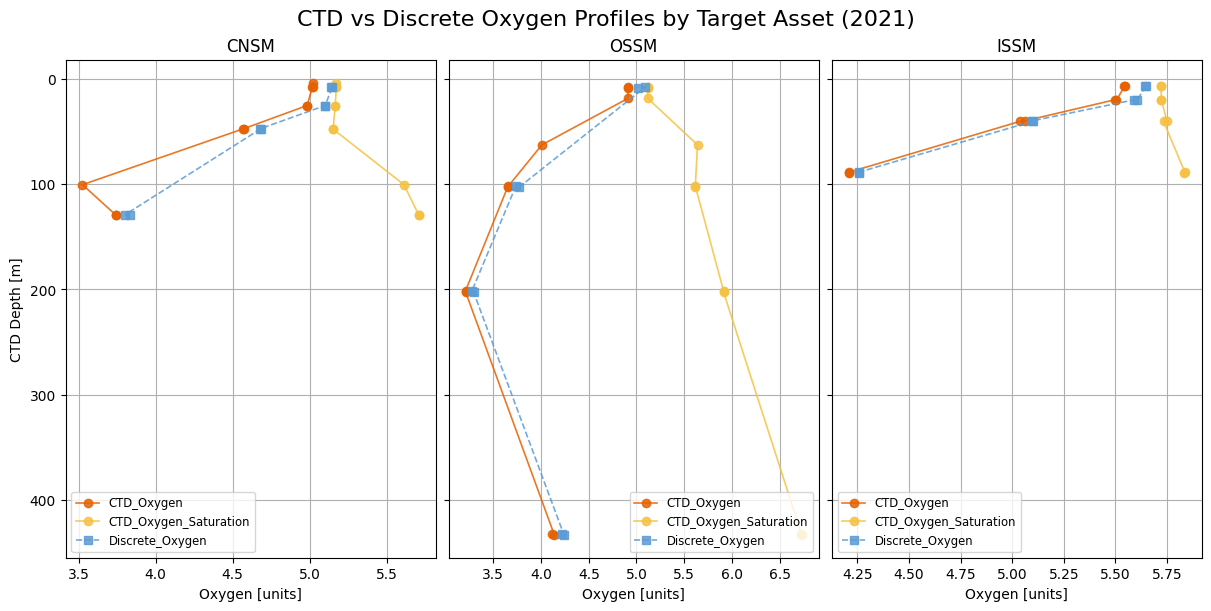

In [92]:
# Default: all assets for Salinity in 2023
#plot_ctd_vs_discrete_profiles(df_qc, year=2021, variable="Salinity")

# Custom: just a few Target_Assets
plot_ctd_vs_discrete_profiles(df_qc, year=2021, variable="Oxygen", target_assets=["CNSM", "OSSM", "ISSM"])



## Variable Time Series by Depth Band (All Assets Combined & Discrete Values Used)
* Mean ± std
* One line per variable (e.g., Oxygen, pH, Nitrate)
* Separate panel per depth band (e.g., 0–50m, 50–200m)


In [117]:
def latlon_map_per_year(df, var="Discrete_Oxygen", year_range=(2018, 2025)):
    """
    Plot one map per year showing lat/lon sampling points colored by a variable.
    
    Parameters:
    - df: DataFrame
    - var: variable to visualize with color (e.g., "Discrete_Oxygen")
    - year_range: tuple (start_year, end_year)
    """
    df = df.copy()
    df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
    df = df[df["Start_Time"].dt.year.between(*year_range)]
    df = df[["Start_Time", "Start_Latitude", "Start_Longitude", var]].dropna()

    if df.empty:
        print(f"❌ No data available for {var} in years {year_range}")
        return

    df["Year"] = df["Start_Time"].dt.year
    years = sorted(df["Year"].unique())

    n_cols = 3
    n_rows = (len(years) + n_cols - 1) // n_cols
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), constrained_layout=True)
    axs = axs.flatten()

    for i, year in enumerate(years):
        ax = axs[i]
        sub = df[df["Year"] == year]
        sc = ax.scatter(sub["Start_Longitude"], sub["Start_Latitude"],
                        c=sub[var], cmap="viridis", edgecolor="k", s=60)
        ax.set_title(f"{year}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True)

    # Hide any unused axes
    for j in range(i + 1, len(axs)):
        axs[j].axis("off")

    # Add one shared colorbar
    cbar = fig.colorbar(sc, ax=axs[:i + 1], orientation="vertical", shrink=0.7)
    cbar.set_label(f"{var} (value)")

    plt.suptitle(f"{var} Distribution by Year (Lat–Lon)", fontsize=16)
    plt.show()

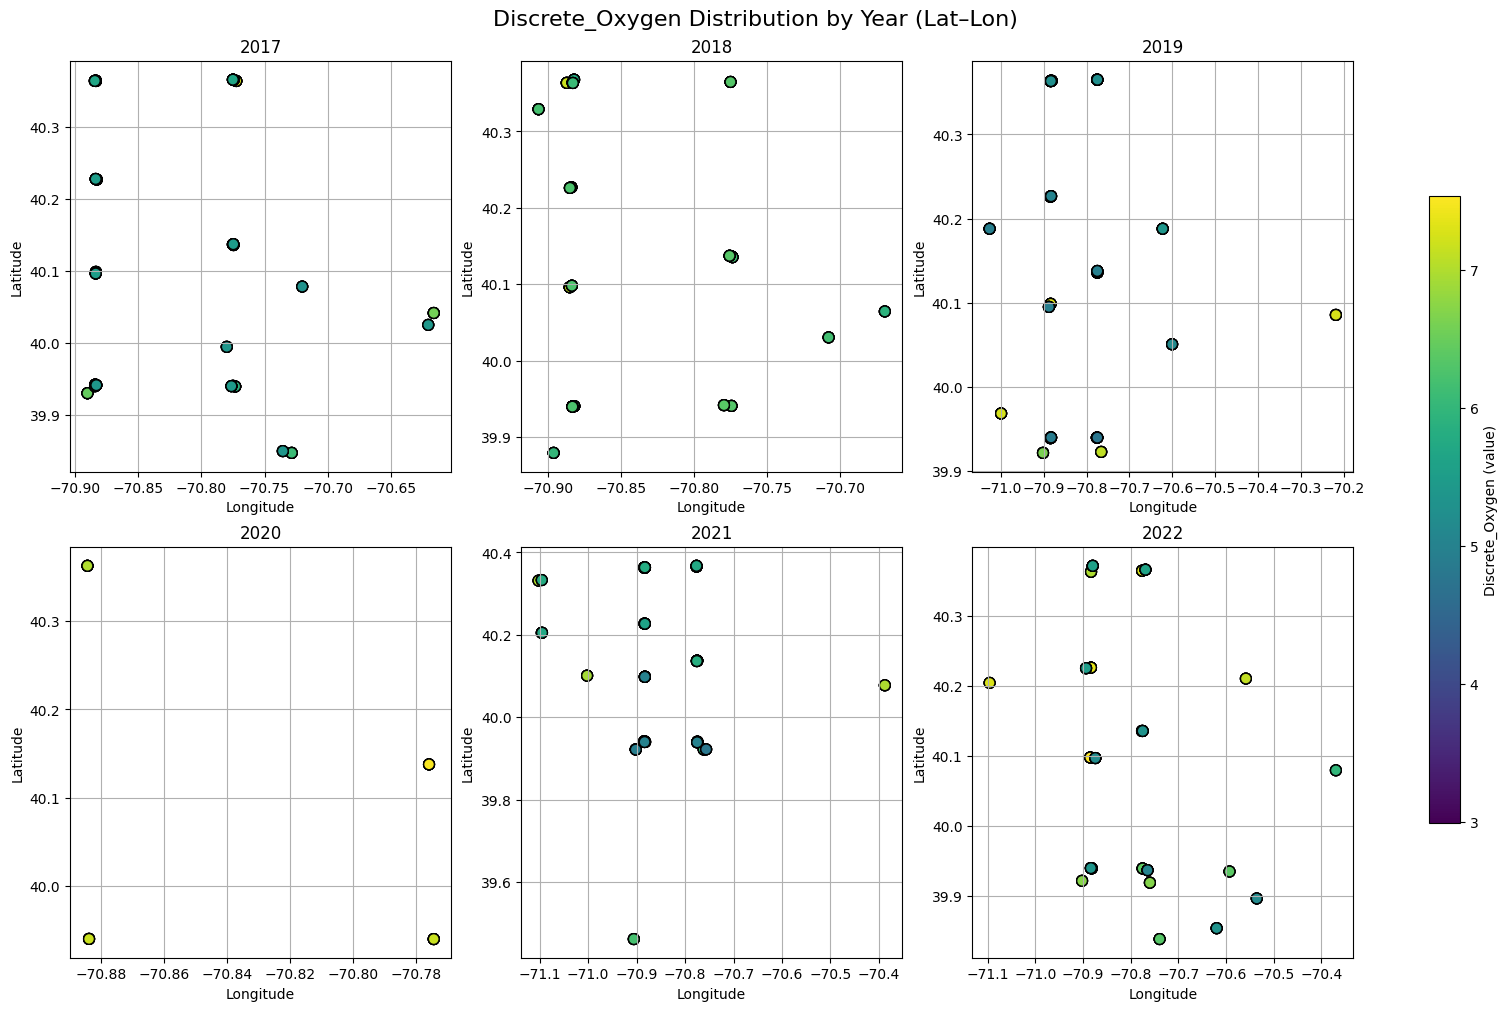

In [119]:
latlon_map_per_year(df_qc, var="Discrete_Oxygen", year_range=(2017, 2023))

## Visualizing Discrete Oxygen Profiles by Cruise and Depth (Hovmöller Plot)
This section creates a heatmap where each column represents a cruise, the Y-axis is depth (deeper at the bottom), and color indicates mean Discrete_Oxygen within 10-meter bins.

In [130]:
def hovmoller_depth_cruise(df, var="Discrete_Oxygen", depth_col="CTD_Depth",
                            bin_size=10, cruise_col="Cruise", season_labels=False):
    """
    Hovmöller-style heatmap to visualize how a water column variable changes with depth over a sequence of cruises.

    WHY THIS IS USEFUL:
    - Shows how vertical structure of a variable (e.g., oxygen, pH) changes over time or across cruises
    - Great for datasets with seasonal cruises (like spring/fall sampling)
    - Highlights interannual or seasonal patterns in the upper water column

    PARAMETERS:
    ----------
    df : pandas DataFrame
        Your dataset including a datetime column (Start_Time), depth, cruise name, and the variable to plot
    var : str
        The name of the variable to visualize (e.g., "Discrete_Oxygen")
    depth_col : str
        The column containing CTD or bottle depth values
    bin_size : int
        Vertical resolution in meters (e.g., bin all depths in 10 m steps)
    cruise_col : str
        Column name that holds cruise ID (e.g., "Cruise")
    season_labels : bool
        If True, uses "Spring/Fall Year" labels instead of raw cruise names

    OUTPUT:
    ------
    A heatmap with:
    - Y-axis: Depth (deeper is lower)
    - X-axis: Cruise or season-year
    - Color: Mean value of the variable in each cruise–depth bin (darker = higher)
    """
    # Copy to avoid modifying original dataframe
    df = df.copy()

    # Convert Start_Time to datetime to allow time-based filtering
    df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")

    # Keep only necessary columns and drop missing data
    df = df[[var, cruise_col, depth_col, "Start_Time"]].dropna()

    if df.empty:
        print(f"❌ No data for {var}")
        return

    # Optional: Replace cruise names with "Spring 2024", "Fall 2024", etc.
    if season_labels:
        df["Season"] = df["Start_Time"].dt.month.map(lambda m: "Spring" if m < 7 else "Fall")
        df["Cruise_Label"] = df["Start_Time"].dt.year.astype(str) + " " + df["Season"]
    else:
        df["Cruise_Label"] = df[cruise_col]

    # Bin depth into regular intervals (e.g., every 10 meters)
    df["Depth_bin"] = (df[depth_col] // bin_size * bin_size).astype(int)

    # Create a pivot table: rows = depth bins, columns = cruise labels, values = mean of selected variable
    pivot = df.groupby(["Depth_bin", "Cruise_Label"])[var].mean().unstack()

    # If using season-year labels, sort columns chronologically
    if season_labels:
        cruise_order = df.groupby("Cruise_Label")["Start_Time"].min().sort_values().index
        pivot = pivot[cruise_order]

    # Plot the heatmap
    fig, ax = plt.subplots(figsize=(1.2 * len(pivot.columns), 6))
    sns.heatmap(
    pivot.sort_index(ascending=False),
    cmap="cividis_r",  # ⬅️ reversed colormap so higher = darker
    cbar_kws={'label': f"{var} (mean)"},
    ax=ax
)

    # Titles and labels
    ax.set_title(f"{var} by Depth and Cruise", fontsize=14)
    ax.set_xlabel("Cruise" if not season_labels else "Season-Year")
    ax.set_ylabel("Depth [m]")

    # Make deeper depths appear lower on Y-axis
    ax.invert_yaxis()

    # Improve layout
    plt.tight_layout()
    plt.show()

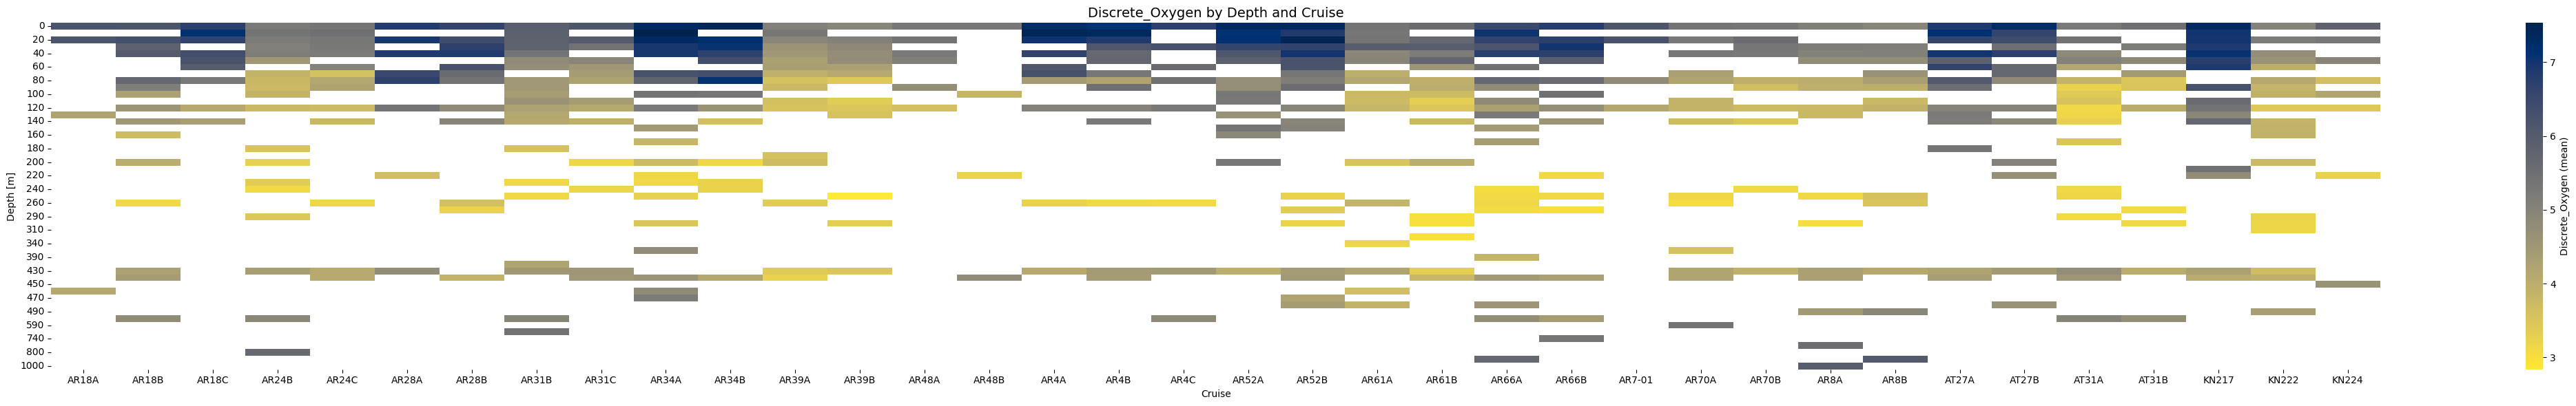

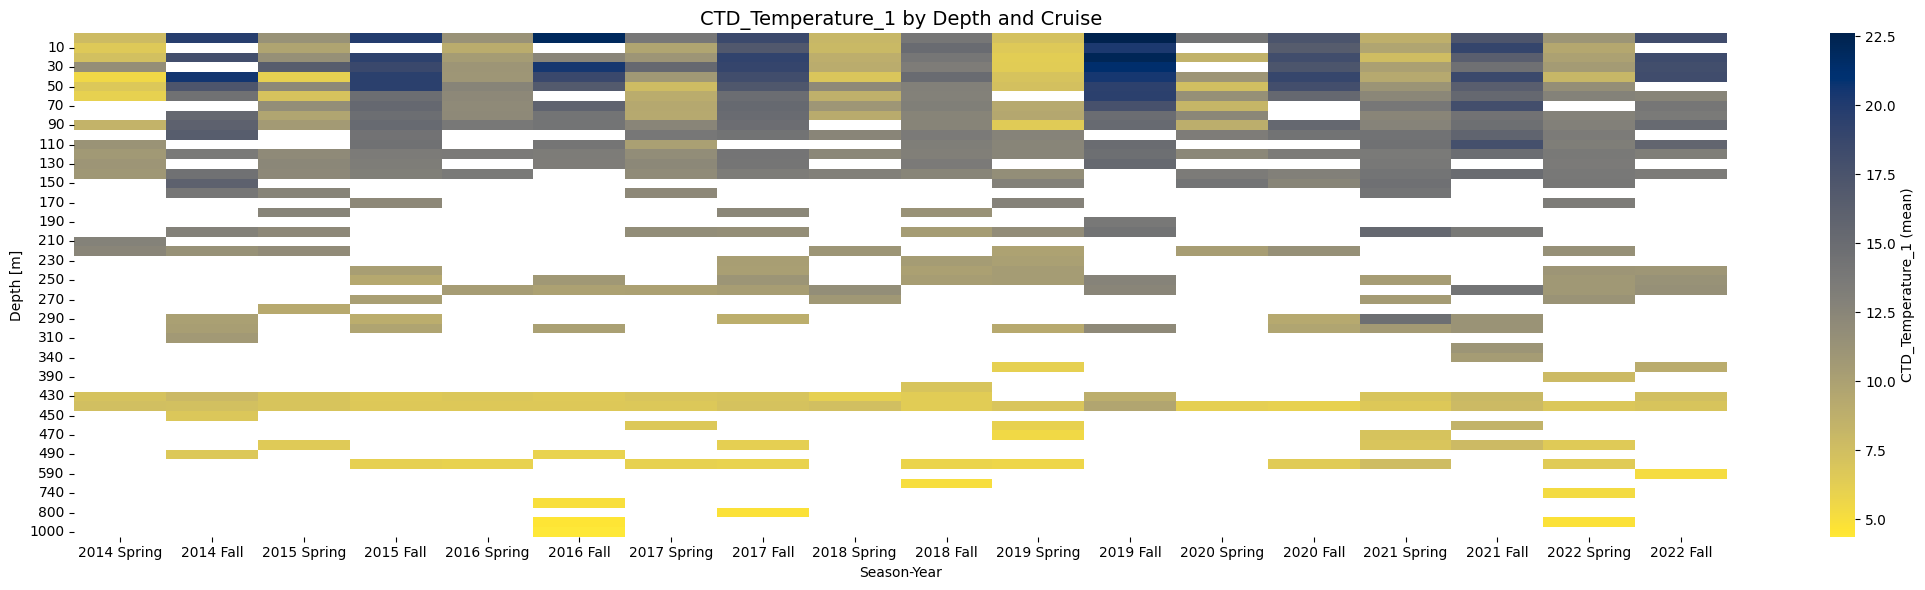

In [133]:
# Option A: by Cruise name
hovmoller_depth_cruise(df_qc, var="Discrete_Oxygen")

# Option B: by Season–Year
hovmoller_depth_cruise(df_qc, var="CTD_Temperature_1", season_labels=True)